# Bank Customer Churn Analysis
## Data Preprocessing


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report


In [3]:
bank = pd.read_csv('./Bank Customer Churn Prediction.csv')
bank.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
bank.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [6]:
bank['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

df = bank.copy()
cate_item = ['country','gender','products_number','credit_card','active_member']

bank['country'] = LabelEncoder().fit_transform(bank['country'])
bank['gender'] = LabelEncoder().fit_transform(bank['gender'])


y = bank['churn'].values.reshape(-1,1)
X = bank.drop(columns="churn").values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4️⃣ 공통 하이퍼파라미터 그리드
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 800]
}

X.shape, y.shape


((10000, 11), (10000, 1))

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold

sf = StratifiedKFold(n_splits=4)
s_gen = sf.split(X, y)
train_idx, valid_idx = next(s_gen)

np.unique(y[train_idx], return_counts=True)
np.unique(y[valid_idx], return_counts=True)

s_kfold = StratifiedKFold(n_splits=4)
s_gen = s_kfold.split(X, y)


max_depth_list = [i for i in range(1,11)]
results = {"max_depth": [], "scores": [], "mean_score": []}


val_result = []
for train_idx, test_idx in s_gen:

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    print("X type: ", type(X_train))
    # 모델링
    max_depth = 5

    model = DecisionTreeClassifier(max_depth=max_depth, random_state=10)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    val_result.append(accuracy_score(y_test, pred))


print("StratifiedKFold: decision tree validation_result")
print(val_result)



X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
StratifiedKFold: decision tree validation_result
[0.8492, 0.8596, 0.8536, 0.8496]


0.11559720750920009

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=10)
X_train.shape, X_test.shape

((7500, 11), (2500, 11))

## Decision Tree

In [16]:
##### DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
print("Depth 조회:", tree.get_depth())
print("Leaf nodes의 개수:", tree.get_n_leaves())

Depth 조회: 3
Leaf nodes의 개수: 8


In [18]:
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_train,
    tree.predict(X_train),
    tree.predict_proba(X_train)[:, 1],
    "Train set 평가결과"
)

Train set 평가결과
정확도: 0.8392
재현율: 0.2513089005235602
정밀도: 0.8609865470852018
F1 점수: 0.3890577507598784
Average Precision: 0.5328020326050065
ROC-AUC Score: 0.797700569498848


In [19]:
print_binary_classification_metrics(
    y_test,
    tree.predict(X_test),
    tree.predict_proba(X_test)[:, 1],
    "Test set 평가결과"
)

Test set 평가결과
정확도: 0.842
재현율: 0.2554027504911591
정밀도: 0.8904109589041096
F1 점수: 0.3969465648854962
Average Precision: 0.5410498881269239
ROC-AUC Score: 0.7910163515781725


In [20]:
pred_train_tree = tree.predict(X_train)
pred_test_tree = tree.predict(X_test)

In [21]:
print("---------------Decision Tree Classifier Train set Classification Report---------------")
print(classification_report(y_train, pred_train_tree))

---------------Decision Tree Classifier Train set Classification Report---------------
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      5972
           1       0.86      0.25      0.39      1528

    accuracy                           0.84      7500
   macro avg       0.85      0.62      0.65      7500
weighted avg       0.84      0.84      0.80      7500



In [22]:
print("---------------Decision Tree Test set Classification Report---------------")
print(classification_report(y_test, pred_test_tree))

---------------Decision Tree Test set Classification Report---------------
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1991
           1       0.89      0.26      0.40       509

    accuracy                           0.84      2500
   macro avg       0.86      0.62      0.65      2500
weighted avg       0.85      0.84      0.80      2500



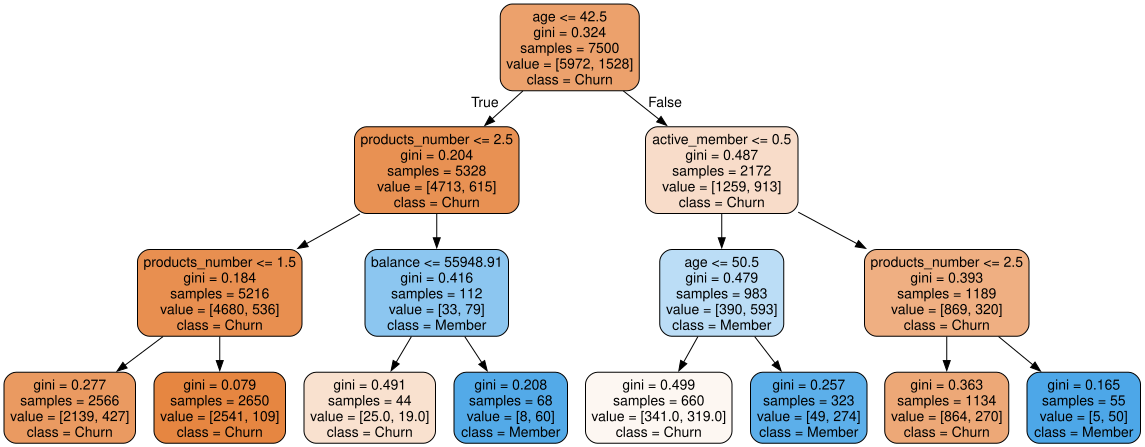

In [23]:
from sklearn.tree import export_graphviz
from graphviz import Source

graph = Source(
    export_graphviz(
        tree,
        feature_names=bank.columns[:-1],
        class_names=['Churn', 'Member'],
        filled=True,
        rounded=True
    )
)
graph

## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=0)
rfc.fit(X_train, y_train)

C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,200
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
## 추론: 클래스 결과
pred_train = rfc.predict(X_train)
pred_test = rfc.predict(X_test)

## 추론: 클래스별 확률 결과
pred_train_rfc = rfc.predict_proba(X_train)
pred_test_rfc = rfc.predict_proba(X_test)

In [26]:
## 평가
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_train, pred_train, pred_train_rfc[:, 1], "Train set 검증결과"
)

Train set 검증결과
정확도: 0.866
재현율: 0.406413612565445
정밀도: 0.8636995827538247
F1 점수: 0.5527369826435247
Average Precision: 0.7242614961691933
ROC-AUC Score: 0.8741090073922634


In [27]:
print_binary_classification_metrics(
    y_test, pred_test, pred_test_rfc[:, 1], "Test set"
)

Test set
정확도: 0.8592
재현율: 0.37721021611001965
정밀도: 0.8458149779735683
F1 점수: 0.5217391304347826
Average Precision: 0.6883563012443401
ROC-AUC Score: 0.8517049709942285


In [28]:
print("---------------Random Forest Classifier Train set Classification Report---------------")
print(classification_report(y_train, pred_train))

---------------Random Forest Classifier Train set Classification Report---------------
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      5972
           1       0.86      0.41      0.55      1528

    accuracy                           0.87      7500
   macro avg       0.86      0.70      0.74      7500
weighted avg       0.87      0.87      0.85      7500



In [29]:
print("---------------Random Forest Classifier Test set Classification Report---------------")
print(classification_report(y_test, pred_test))

---------------Random Forest Classifier Test set Classification Report---------------
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1991
           1       0.85      0.38      0.52       509

    accuracy                           0.86      2500
   macro avg       0.85      0.68      0.72      2500
weighted avg       0.86      0.86      0.84      2500



In [30]:
fi = pd.Series(rfc.feature_importances_).sort_values(ascending=False)
fi

4     0.427110
7     0.295840
9     0.097474
6     0.054088
1     0.029577
2     0.022184
0     0.021477
10    0.019908
3     0.019577
5     0.010871
8     0.001894
dtype: float64

### PRC + AP Score

In [31]:
##### DecisionTree의 PrecisionRecall 커브 그리기 + AP Score 계산.
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

# 모델이 추정한 positive 확률
test_proba_tree = tree.predict_proba(X_test)[:, 1]
test_proba_rfc = rfc.predict_proba(X_test)[:, 1]

tree_ap = average_precision_score(y_test, test_proba_tree)  # (y정답, 모델이 예측한 이탈한 확률)
rfc_ap = average_precision_score(y_test, test_proba_rfc)
print("DecisionTree Average Precision Score:", tree_ap)
print("RandomForest Average Precision Score:", rfc_ap)

DecisionTree Average Precision Score: 0.5410498881269239
RandomForest Average Precision Score: 0.6883563012443401


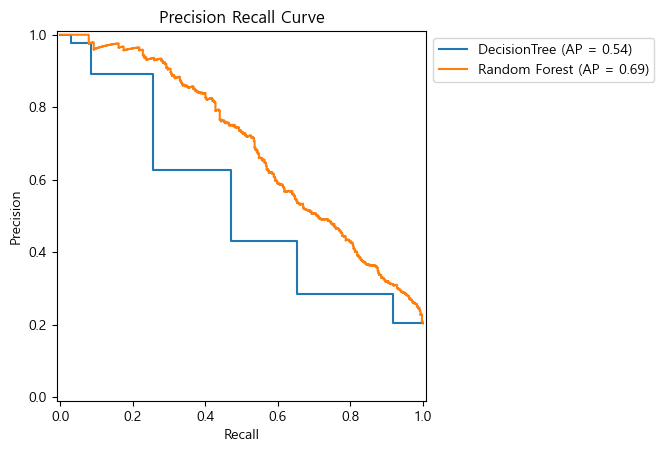

In [32]:
precisions1, recalls1, _ = precision_recall_curve(y_test, test_proba_tree)
precisions2, recalls2, _ = precision_recall_curve(y_test, test_proba_rfc)

ax = plt.gca()

disp_tree = PrecisionRecallDisplay(precisions1, recalls1,  average_precision=tree_ap, estimator_name="DecisionTree" )
disp_tree.plot(ax=ax)

disp_rfc = PrecisionRecallDisplay(precisions2, recalls2, average_precision=rfc_ap, estimator_name="Random Forest")
disp_rfc.plot(ax=ax)

plt.title("Precision Recall Curve")
plt.legend(bbox_to_anchor=(1,1), loc="upper left")
plt.show()

### ROC-AUC

In [33]:
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

# roc-auc score
tree_roc = roc_auc_score(y_test, test_proba_tree)
rfc_roc =roc_auc_score(y_test, test_proba_rfc)

print("Tree:", tree_roc)
print("RFC:", rfc_roc)

fpr1, recall1, thresh1 = roc_curve(y_test, test_proba_tree)
fpr2, recall2, thresh2 = roc_curve(y_test, test_proba_rfc)

pd.DataFrame({"Thresh": thresh1,"FPR":fpr1,"Recall":recall1})


Tree: 0.7910163515781725
RFC: 0.8517049709942285


,Thresh,FPR,Recall
0,inf,0.000000,0.000000
1,0.909091,0.000000,0.029470
2,0.882353,0.000502,0.084479
3,0.848297,0.008036,0.255403
4,0.483333,0.068307,0.447937
5,0.431818,0.071823,0.471513
6,0.238095,0.219990,0.652259
7,0.166407,0.589151,0.917485
8,0.041132,1.000000,1.000000


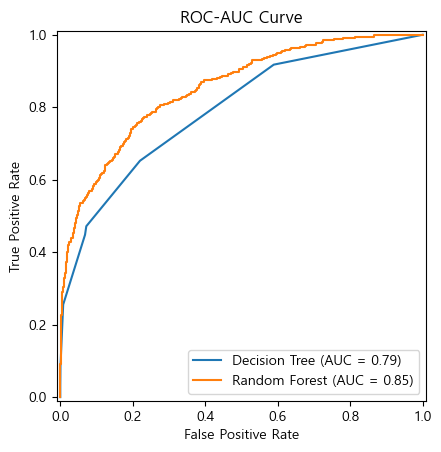

In [34]:
ax = plt.gca()
ax.set_title("ROC-AUC Curve")
disp_roc_tree = RocCurveDisplay(
    fpr=fpr1, tpr=recall1,
    roc_auc=tree_roc,
    name="Decision Tree"
)
disp_roc_tree.plot(ax=ax)

disp_roc_rfc = RocCurveDisplay(
    fpr=fpr2, tpr=recall2,
    roc_auc=rfc_roc,
    name="Random Forest"
)
disp_roc_rfc.plot(ax=ax)

plt.show()

## XGBoost

In [35]:
from xgboost import XGBClassifier # , XGBRegressor
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=10,eval_metric='auc')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [36]:
print_binary_classification_metrics(
    y_train, xgb.predict(X_train), xgb.predict_proba(X_train)[:, 1], "Trainset"
)


Trainset
정확도: 0.8788
재현율: 0.5032722513089005
정밀도: 0.8367791077257889
F1 점수: 0.6285247241520229
Average Precision: 0.765738882591175
ROC-AUC Score: 0.8978798967607999


In [37]:
print_binary_classification_metrics(
    y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:, 1], "Test set"
)

Test set
정확도: 0.8648
재현율: 0.4538310412573674
정밀도: 0.7938144329896907
F1 점수: 0.5775
Average Precision: 0.7044251024687589
ROC-AUC Score: 0.8620841922245388


In [38]:
pd.Series(xgb.feature_importances_).sort_values(ascending=False)

7     0.236909
9     0.232930
4     0.196773
2     0.084375
3     0.072462
6     0.048733
8     0.030889
5     0.026453
1     0.026264
0     0.023681
10    0.020531
dtype: float32

## Light GBM

In [39]:
from lightgbm import LGBMRegressor, LGBMClassifier
lgbm = LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=10)
lgbm.fit(X_train, y_train)

C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 1528, number of negative: 5972
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1112
[LightGBM] [Info] Number of data points in the train set: 7500, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203733 -> initscore=-1.363122
[LightGBM] [Info] Start training from score -1.363122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [40]:
print_binary_classification_metrics(
    y_train, lgbm.predict(X_train), lgbm.predict_proba(X_train)[:, 1], "Trainset"
)

Trainset
정확도: 0.8828
재현율: 0.5150523560209425
정밀도: 0.8508108108108108
F1 점수: 0.6416632694659601
Average Precision: 0.7761703911432518
ROC-AUC Score: 0.903544639381687


C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [41]:
print_binary_classification_metrics(
    y_test, lgbm.predict(X_test), lgbm.predict_proba(X_test)[:, 1], "Test set"
)

Test set
정확도: 0.8652
재현율: 0.4636542239685658
정밀도: 0.7866666666666666
F1 점수: 0.5834363411619283
Average Precision: 0.7088471657222055
ROC-AUC Score: 0.8631997229181612


C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
pd.Series(lgbm.feature_importances_).sort_values(ascending=False)

4     2360
6     2183
7     1453
1     1419
10    1264
0     1144
2      796
9      602
5      515
3      405
8       33
dtype: int32

## CatBoost

In [43]:
from catboost import CatBoostClassifier
cat = CatBoostClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=10)
cat.fit(X_train, y_train)

0:	learn: 0.6849074	total: 143ms	remaining: 2m 23s
1:	learn: 0.6780301	total: 149ms	remaining: 1m 14s
2:	learn: 0.6714445	total: 155ms	remaining: 51.5s
3:	learn: 0.6640249	total: 160ms	remaining: 39.9s
4:	learn: 0.6578276	total: 164ms	remaining: 32.7s
5:	learn: 0.6517221	total: 168ms	remaining: 27.8s
6:	learn: 0.6444789	total: 171ms	remaining: 24.2s
7:	learn: 0.6376134	total: 173ms	remaining: 21.4s
8:	learn: 0.6308689	total: 175ms	remaining: 19.3s
9:	learn: 0.6245648	total: 177ms	remaining: 17.6s
10:	learn: 0.6181350	total: 180ms	remaining: 16.1s
11:	learn: 0.6127695	total: 182ms	remaining: 15s
12:	learn: 0.6069422	total: 184ms	remaining: 14s
13:	learn: 0.6018858	total: 186ms	remaining: 13.1s
14:	learn: 0.5962702	total: 188ms	remaining: 12.4s
15:	learn: 0.5917111	total: 190ms	remaining: 11.7s
16:	learn: 0.5875147	total: 192ms	remaining: 11.1s
17:	learn: 0.5821471	total: 194ms	remaining: 10.6s
18:	learn: 0.5767526	total: 197ms	remaining: 10.2s
19:	learn: 0.5715540	total: 199ms	remaining

In [44]:
print_binary_classification_metrics(
    y_train, cat.predict(X_train), cat.predict_proba(X_train)[:, 1], "Trainset"
)

Trainset
정확도: 0.8726666666666667
재현율: 0.4882198952879581
정밀도: 0.8117519042437432
F1 점수: 0.6097261953412342
Average Precision: 0.7425945696377201
ROC-AUC Score: 0.8846356075297287


In [45]:
print_binary_classification_metrics(
    y_test, cat.predict(X_test), cat.predict_proba(X_test)[:, 1], "Testset"
)

Testset
정확도: 0.866
재현율: 0.44793713163064836
정밀도: 0.8085106382978723
F1 점수: 0.5764854614412137
Average Precision: 0.7171638333507451
ROC-AUC Score: 0.8686219618933531


In [46]:
import optuna

from catboost import CatBoostClassifier
cat = CatBoostClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=10)
cat.fit(X_train, y_train)


C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0:	learn: 0.6849074	total: 5.81ms	remaining: 5.81s
1:	learn: 0.6780301	total: 12.5ms	remaining: 6.25s
2:	learn: 0.6714445	total: 20.9ms	remaining: 6.93s
3:	learn: 0.6640249	total: 27.8ms	remaining: 6.93s
4:	learn: 0.6578276	total: 34.6ms	remaining: 6.88s
5:	learn: 0.6517221	total: 40.8ms	remaining: 6.76s
6:	learn: 0.6444789	total: 45.6ms	remaining: 6.47s
7:	learn: 0.6376134	total: 50.3ms	remaining: 6.24s
8:	learn: 0.6308689	total: 55.6ms	remaining: 6.12s
9:	learn: 0.6245648	total: 59.2ms	remaining: 5.86s
10:	learn: 0.6181350	total: 62.8ms	remaining: 5.65s
11:	learn: 0.6127695	total: 67.7ms	remaining: 5.58s
12:	learn: 0.6069422	total: 72.1ms	remaining: 5.48s
13:	learn: 0.6018858	total: 77.4ms	remaining: 5.45s
14:	learn: 0.5962702	total: 81.9ms	remaining: 5.38s
15:	learn: 0.5917111	total: 88.7ms	remaining: 5.46s
16:	learn: 0.5875147	total: 93ms	remaining: 5.38s
17:	learn: 0.5821471	total: 97.1ms	remaining: 5.29s
18:	learn: 0.5767526	total: 101ms	remaining: 5.23s
19:	learn: 0.5715540	tota

## Optuna

In [47]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    classifier_name = trial.suggest_categorical('classifier', ['XGBoost', 'CatBoost', 'LightGBM'])

    if classifier_name == 'XGBoost':
        params = {
            'subsample': trial.suggest_float('subsample', 0.7, 0.8),
            'n_estimators': trial.suggest_int('n_estimators', 100, 150),
            'min_child_weight': trial.suggest_int('min_child_weight', 6, 8),
            'max_depth': trial.suggest_int('max_depth', 8, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.1, 0.15),
            'gamma': trial.suggest_float('gamma', 0.1, 0.2),
            #'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.5),
            'random_state': 42
        }
        classifier_obj = XGBClassifier(**params)
    elif classifier_name.startswith('CatBoost'):
        params = {
            'iterations': trial.suggest_int('iterations', 150, 200),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15),
            'depth': trial.suggest_int('depth', 6, 8),
            'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 8, 9),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'random_state': 42,
            'verbose': False
        }
        classifier_obj = CatBoostClassifier(**params)


    # elif classifier_name == 'RandomForest':
    #     params = {
    #         'iterations': trial.suggest_int('iterations', 150, 200),
    #         'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15),
    #         'depth': trial.suggest_int('depth', 6, 8),
    #         'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 8, 9),
    #         'border_count': trial.suggest_int('border_count', 32, 255),
    #         'random_state': 42,
    #         'verbose': False
    #     }
    #     classifier_obj = RandomForestClassifier(**params)


    elif classifier_name == 'LightGBM':
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 20, 40),
            'n_estimators': trial.suggest_int('n_estimators', 100, 200),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
            'max_depth': trial.suggest_int('max_depth', 10, 30),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
             #'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
            'random_state': 42,
            'force_row_wise': True,
            'verbose': -1
        }
        classifier_obj = LGBMClassifier(**params)

    classifier_obj.fit(X_train, y_train)
    y_pred = classifier_obj.predict(X_test)
    accuracy = cross_val_score(classifier_obj, X_train, y_pred, cv=5, scoring='f1').mean()
    return accuracy


In [48]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)
print(study.best_trial.params)

[I 2025-11-21 17:39:19,112] A new study created in memory with name: no-name-4bf77c97-3513-4f5b-8904-5acfe96a5a90
[W 2025-11-21 17:39:19,806] Trial 0 failed with parameters: {'classifier': 'CatBoost', 'iterations': 192, 'learning_rate': 0.10115904535805381, 'depth': 8, 'l2_leaf_reg': 8, 'border_count': 63} because of the following error: ValueError('Found input variables with inconsistent numbers of samples: [7500, 2500]').
Traceback (most recent call last):
  File "C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Playdata\AppData\Local\Temp\ipykernel_5336\1871070129.py", line 62, in objective
    accuracy = cross_val_score(classifier_obj, X_train, y_pred, cv=5, scoring='f1').mean()
               ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ut

ValueError: Found input variables with inconsistent numbers of samples: [7500, 2500]